<a href="https://colab.research.google.com/github/Rohan-Chandra-04/Butterfly_image_classification/blob/resnet_after_augmentation1/resnet_arch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d "phucthaiv02/butterfly-image-classification"


In [2]:
import torch
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import os

torch.manual_seed(45)

In [ ]:
!unzip butterfly-image-classification.zip
!ls /content

In [4]:
!ls /content

butterfly-image-classification.zip  sample_data  test  Testing_set.csv	train  Training_set.csv


In [5]:
df = pd.read_csv('Training_set.csv')
df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [6]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert label names to numbers
df["label"] = label_encoder.fit_transform(df["label"])

# Save encoded labels back to CSV (optional)
df.to_csv("encoded_labels.csv", index=False)

# Print mapping
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))
df.head()

{'ADONIS': 0, 'AFRICAN GIANT SWALLOWTAIL': 1, 'AMERICAN SNOOT': 2, 'AN 88': 3, 'APPOLLO': 4, 'ATALA': 5, 'BANDED ORANGE HELICONIAN': 6, 'BANDED PEACOCK': 7, 'BECKERS WHITE': 8, 'BLACK HAIRSTREAK': 9, 'BLUE MORPHO': 10, 'BLUE SPOTTED CROW': 11, 'BROWN SIPROETA': 12, 'CABBAGE WHITE': 13, 'CAIRNS BIRDWING': 14, 'CHECQUERED SKIPPER': 15, 'CHESTNUT': 16, 'CLEOPATRA': 17, 'CLODIUS PARNASSIAN': 18, 'CLOUDED SULPHUR': 19, 'COMMON BANDED AWL': 20, 'COMMON WOOD-NYMPH': 21, 'COPPER TAIL': 22, 'CRECENT': 23, 'CRIMSON PATCH': 24, 'DANAID EGGFLY': 25, 'EASTERN COMA': 26, 'EASTERN DAPPLE WHITE': 27, 'EASTERN PINE ELFIN': 28, 'ELBOWED PIERROT': 29, 'GOLD BANDED': 30, 'GREAT EGGFLY': 31, 'GREAT JAY': 32, 'GREEN CELLED CATTLEHEART': 33, 'GREY HAIRSTREAK': 34, 'INDRA SWALLOW': 35, 'IPHICLUS SISTER': 36, 'JULIA': 37, 'LARGE MARBLE': 38, 'MALACHITE': 39, 'MANGROVE SKIPPER': 40, 'MESTRA': 41, 'METALMARK': 42, 'MILBERTS TORTOISESHELL': 43, 'MONARCH': 44, 'MOURNING CLOAK': 45, 'ORANGE OAKLEAF': 46, 'ORANGE TI

,filename,label
0,Image_1.jpg,66
1,Image_2.jpg,0
2,Image_3.jpg,12
3,Image_4.jpg,44
4,Image_5.jpg,33


In [7]:
!ls /content/

butterfly-image-classification.zip  sample_data  Testing_set.csv  Training_set.csv
encoded_labels.csv		    test	 train


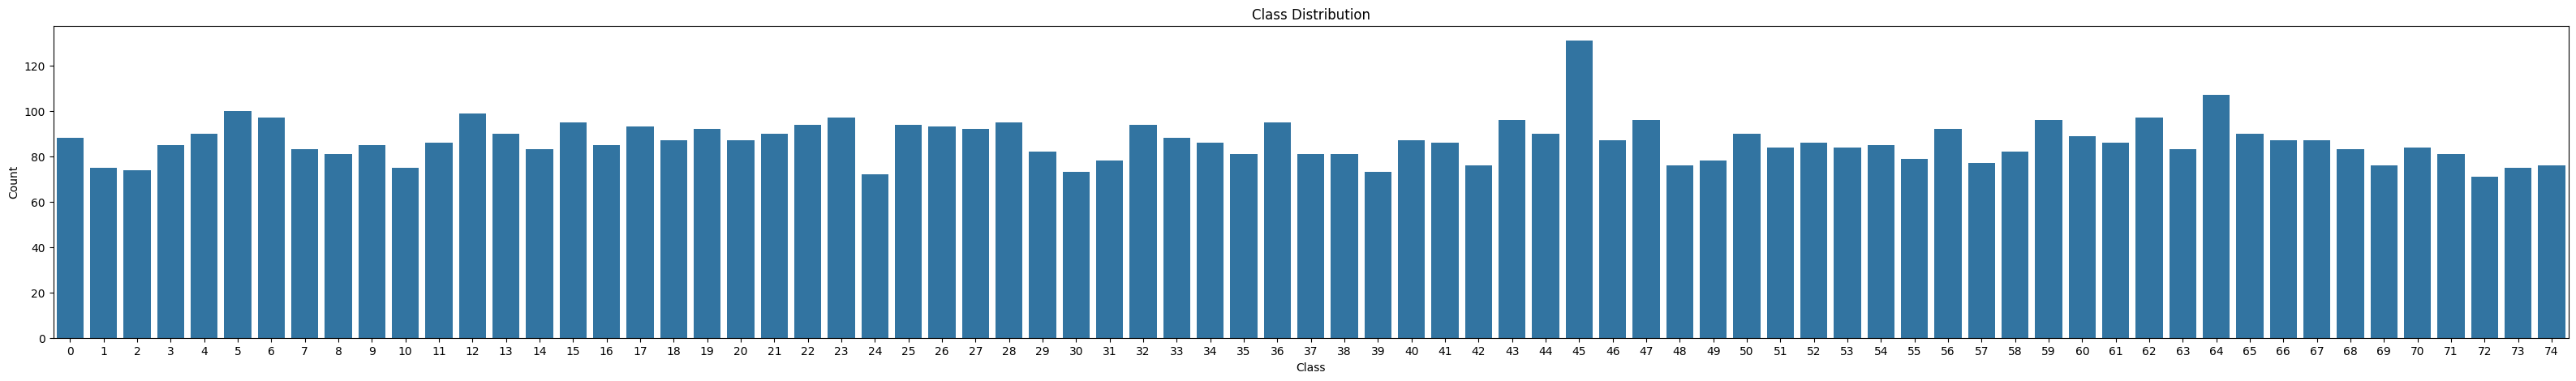

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure( figsize=(40, 5))
sns.countplot(x=df["label"] )
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

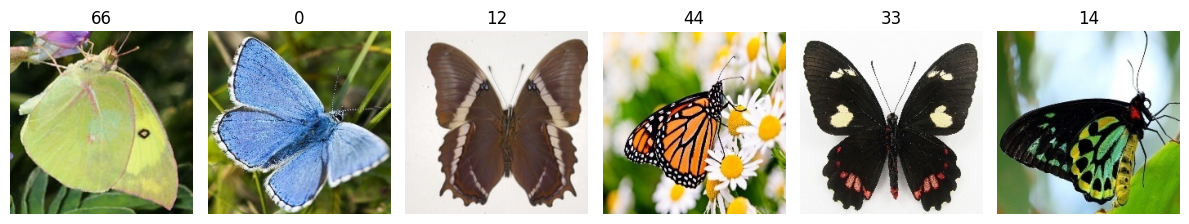

In [9]:
fig, axes = plt.subplots(1, 6, figsize=(12, 6))

# Loop through the selected images and display them
for i in range(0, 6):

    img = Image.open('/content/train/' + f'Image_{i+1}.jpg')  # Open the image

    # Plot the image
    axes[i].imshow(img)
    axes[i].axis("off")  # Hide axes
    axes[i].set_title(df.iloc[i, 1])

# Show the plot
plt.tight_layout()
plt.show()

In [10]:
class ImageDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.data = pd.read_csv(csv_path)  # Load encoded CSV
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])  # Get image path
        image = Image.open(img_path).convert("RGB")  # Load image
        label = self.data.iloc[idx, 1]  # Get encoded label (already a number)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)  # Convert label to tensor

# Define transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),     # Slightly larger before cropping
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),  # Randomly crop important regions
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),  # Increase rotation variation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # More variation
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),  # Increase shift for more randomness
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Create dataset and dataloader
dataset = ImageDataset(csv_path="encoded_labels.csv", img_dir="/content/train", transform=transform)
dataset[0][0].shape

torch.Size([3, 224, 224])

In [11]:
# Define split ratio
from torch.utils.data import random_split


train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, stratify=df['label'])

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")


Train size: 5199, Test size: 1300


<ipython-input-12-611d2341839c>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(count_labels.keys()), y=list(count_labels.values()), palette="viridis")


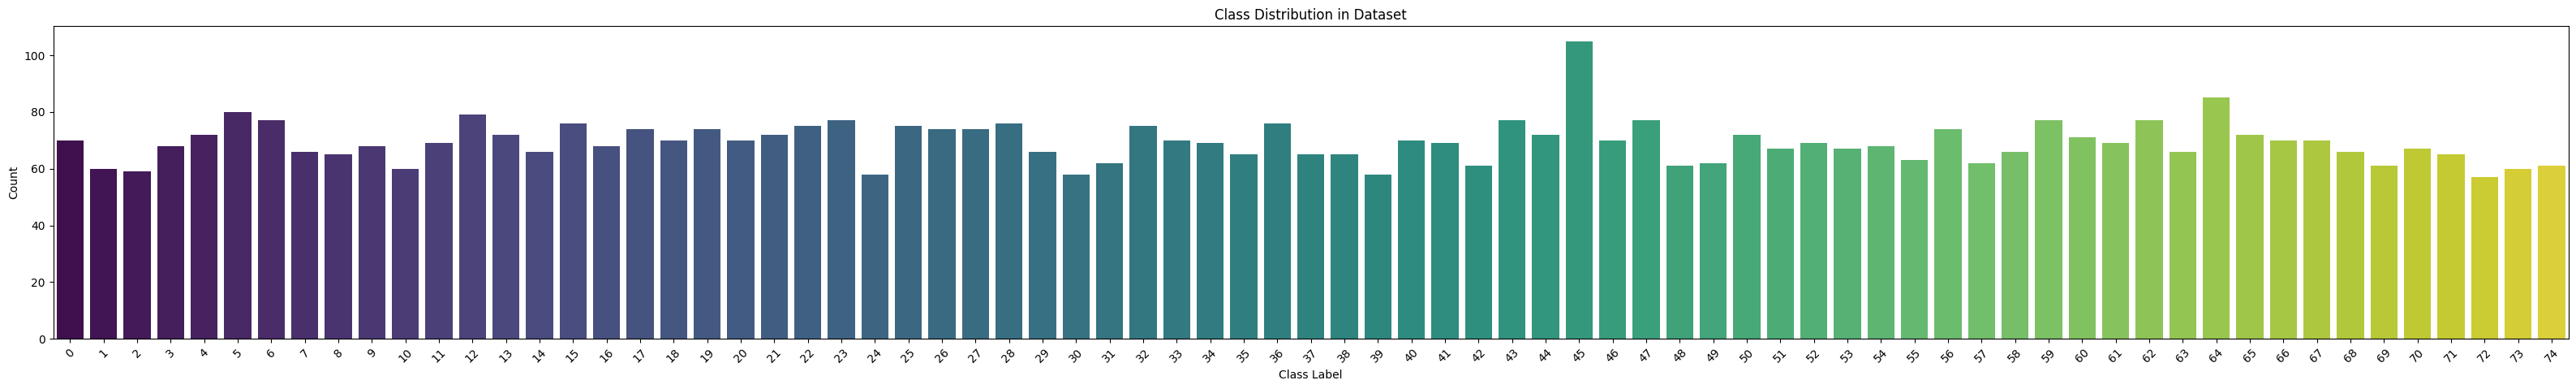

In [12]:
from collections import Counter

count_labels = Counter()

for _, label in train_dataset:
  count_labels[int(label.item())] += 1

plt.figure(figsize=(40, 5))
sns.barplot(x=list(count_labels.keys()), y=list(count_labels.values()), palette="viridis")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=45)  # Rotate labels if they are long
plt.show()

<ipython-input-13-7e99550e18aa>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(count_labels1.keys()), y=list(count_labels1.values()), palette="viridis")


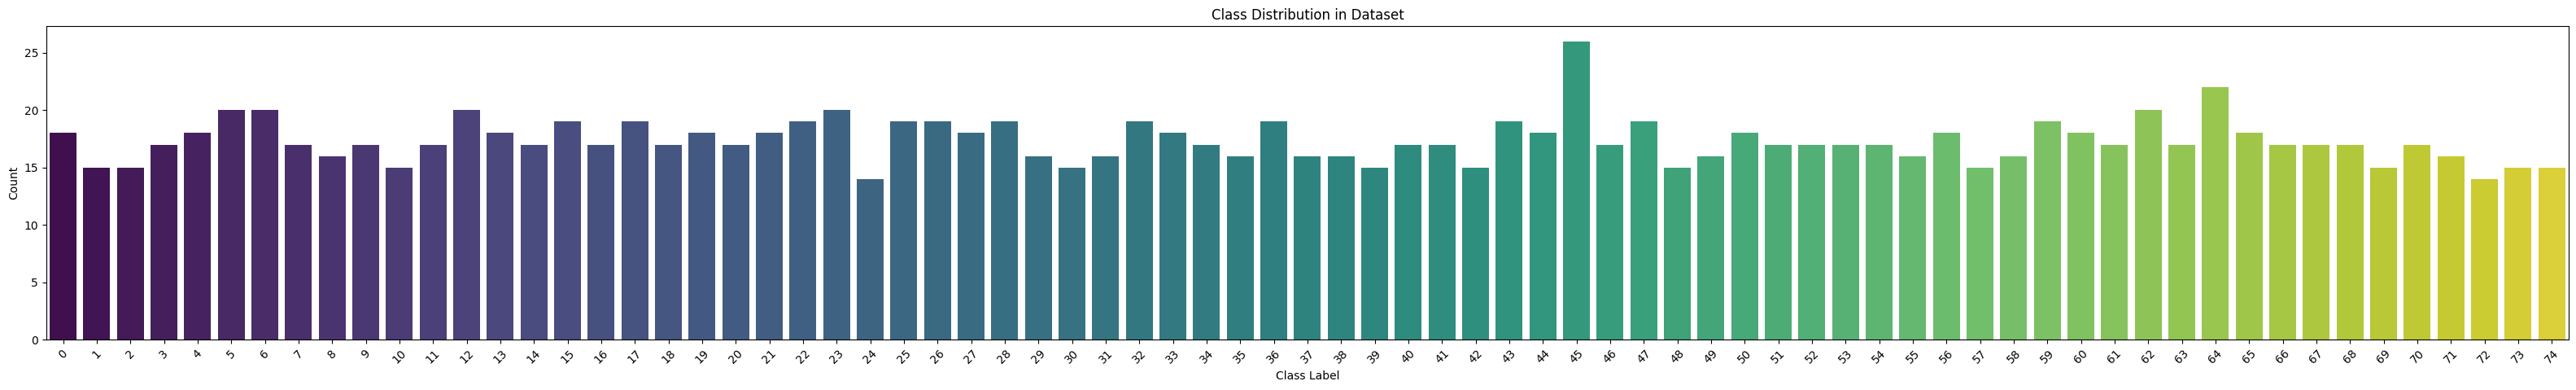

In [13]:
count_labels1 = Counter()

for _, label in test_dataset:
  count_labels1[int(label.item())] += 1

plt.figure(figsize=(40, 5))
sns.barplot(x=list(count_labels1.keys()), y=list(count_labels1.values()), palette="viridis")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=45)  # Rotate labels if they are long
plt.show()

In [14]:
# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Verify DataLoader Works
for images, labels in train_loader:
    print(f"Batch size: {images.shape}, Labels: {labels.shape}")
    break  # Check only one batch


Batch size: torch.Size([64, 3, 224, 224]), Labels: torch.Size([64])


In [15]:
import torch.nn as nn
import torch.optim as optim

class ResidualBlock(nn.Module):
        def __init__(self, in_channels, out_channels, stride = 1, downsample = None):
            super(ResidualBlock, self).__init__()
            self.conv1 = nn.Sequential(
                            nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1),
                            nn.BatchNorm2d(out_channels),
                            nn.ReLU())
            self.conv2 = nn.Sequential(
                            nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1),
                            nn.BatchNorm2d(out_channels))
            self.downsample = downsample
            self.relu = nn.ReLU()
            self.out_channels = out_channels

        def forward(self, x):
            residual = x
            out = self.conv1(x)
            out = self.conv2(out)
            if self.downsample:
                residual = self.downsample(x)
            out += residual
            out = self.relu(out)
            return out

class ResNet(nn.Module):
        def __init__(self, block, layers, num_classes = 10):
            super(ResNet, self).__init__()
            self.inplanes = 64
            self.conv1 = nn.Sequential(
                            nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
                            nn.BatchNorm2d(64),
                            nn.ReLU())
            self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
            self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
            self.layer1 = self._make_layer(block, 128, layers[1], stride = 2)
            self.layer2 = self._make_layer(block, 256, layers[2], stride = 2)
            self.layer3 = self._make_layer(block, 512, layers[3], stride = 2)
            self.avgpool = nn.AvgPool2d(7, stride=1)
            self.dropout = nn.Dropout(0.3)
            self.fc = nn.Linear(512, num_classes)

        def _make_layer(self, block, planes, blocks, stride=1):
            downsample = None
            if stride != 1 or self.inplanes != planes:

                downsample = nn.Sequential(
                    nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                    nn.BatchNorm2d(planes),
                )
            layers = []
            layers.append(block(self.inplanes, planes, stride, downsample))
            self.inplanes = planes
            for i in range(1, blocks):
                layers.append(block(self.inplanes, planes))

            return nn.Sequential(*layers)

        def forward(self, x):
            x = self.conv1(x)
            x = self.maxpool(x)
            x = self.layer0(x)
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)

            x = self.avgpool(x)
            x = x.view(x.size(0), -1)
            x = self.fc(x)

            return x

num_classes = 75
model = ResNet(ResidualBlock, [3, 4, 6, 3], num_classes)
# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(device)

cuda


In [17]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # Suitable for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Example training loop
num_epochs = 30
train_losses = []
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    correct = 0
    total = 0
    running_loss = 0.0

    for images, labels in train_loader:  # Assuming train_loader is already defined
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        _, predicted = torch.max(outputs, 1)
        correct += (labels==predicted).sum().item()

        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        running_loss += loss.item()
        total += 64

    if train_losses and running_loss>=train_losses[-1]:
      break
    train_losses.append(running_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"accuracy of model at this epoch is: {(correct/total)*100}")


Epoch [1/30], Loss: 3.5993
accuracy of model at this epoch is: 12.652439024390244
Epoch [2/30], Loss: 3.1925
accuracy of model at this epoch is: 20.67454268292683
Epoch [3/30], Loss: 2.9417
accuracy of model at this epoch is: 28.10594512195122
Epoch [4/30], Loss: 2.7113
accuracy of model at this epoch is: 35.86128048780488
Epoch [5/30], Loss: 2.5255
accuracy of model at this epoch is: 41.15853658536585
Epoch [6/30], Loss: 2.3901
accuracy of model at this epoch is: 44.66463414634146
Epoch [7/30], Loss: 2.2139
accuracy of model at this epoch is: 50.762195121951216
Epoch [8/30], Loss: 2.0972
accuracy of model at this epoch is: 54.954268292682926
Epoch [9/30], Loss: 1.9349
accuracy of model at this epoch is: 60.327743902439025
Epoch [10/30], Loss: 1.8755
accuracy of model at this epoch is: 63.92911585365854
Epoch [11/30], Loss: 1.7427
accuracy of model at this epoch is: 67.94969512195121
Epoch [12/30], Loss: 1.6589
accuracy of model at this epoch is: 71.2842987804878
Epoch [13/30], Loss: 1

KeyboardInterrupt: 

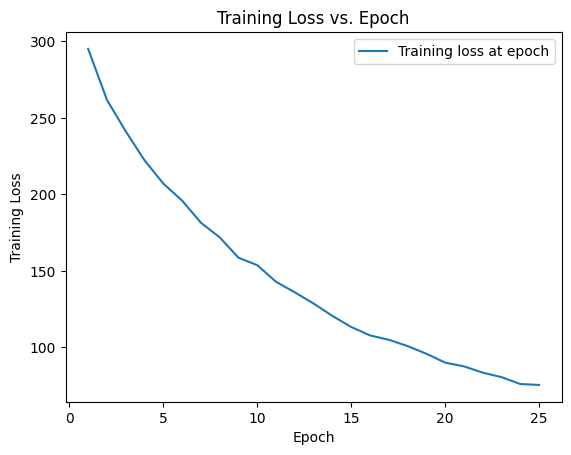

In [18]:
#iou_at_epoch = [iou.cpu().item() for iou in iou_at_epoch]

plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training loss at epoch')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Epoch')
plt.legend()
plt.show()

In [19]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, 'resnet_model.pth')

In [20]:
model.eval()  # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # Disable gradient computation for evaluation
    flag = True
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)  # Get model predictions
        _, predicted = torch.max(outputs, 1)  # Get class with highest score
        correct += (predicted == labels).sum().item()  # Count correct predictions
        total += labels.size(0)
accuracy = 100 * correct / total
print(f'accuracy of my model: {accuracy}')

accuracy of my model: 69.46153846153847


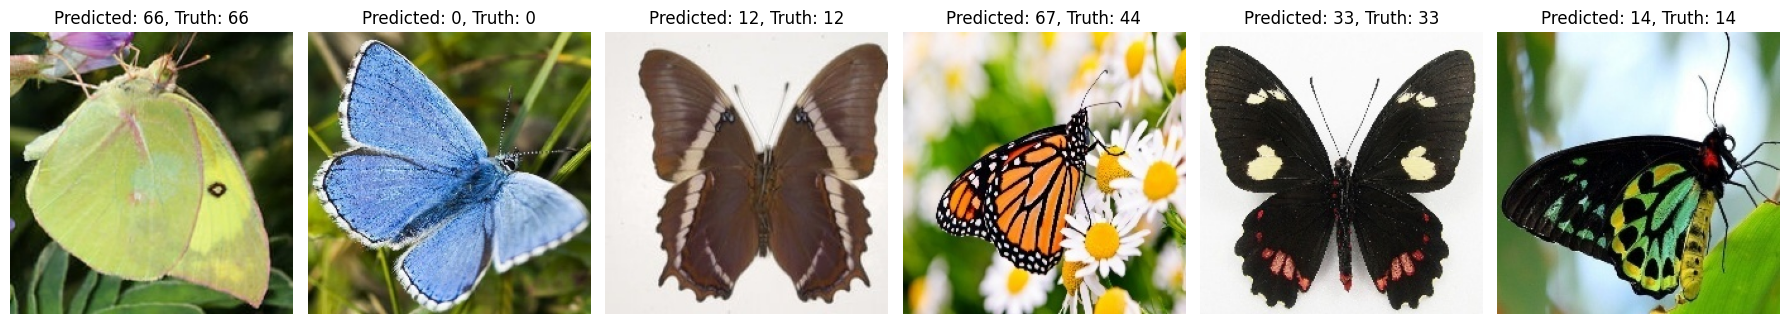

In [21]:
fig, axes = plt.subplots(1, 6, figsize=(18, 6))

# Loop through selected images and display them
for i in range(6):
    img_path = f"/content/train/Image_{i+1}.jpg"
    img = Image.open(img_path)  # Open the image

    image = img.convert("RGB")  # Convert to RGB if not already
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Predict
    with torch.no_grad():
        output = model(image)
        _, pred_label = torch.max(output, 1)

    # Plot the image
    axes[i].imshow(img)
    axes[i].axis("off")  # Hide axes
    axes[i].set_title(f"Predicted: {pred_label.item()}, Truth: {df.iloc[i, 1]}")

# Show the plot
plt.tight_layout()
plt.show()
